## 01_Sample Explanotary Analysis 
This notebook  is developed to explore summary data from the Climate Reporting Entity (CRE) Search Hub. 

In [8]:
import ast, re, time, os, requests
import pandas as pd
import numpy as np
from datetime import date
import seaborn as sns 
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
import textwrap

# ── Publication style ──────────────────────────────────────────────────────────
rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
})


def make_autopct(values):
    def autopct(pct):
        count = int(round(pct * sum(values) / 100))
        return f'{count}\n({pct:.1f}%)'
    return autopct

def classify_status(text):
    t = str(text).lower()
    if re.search(r'(select to view|click to view)', t):
        return 'Submitted'
    elif 'not required to lodge' in t:
        return 'Not required to lodge'
    elif 'due by' in t:
        return 'Not yet submitted'
    else:
        return 'Unknown'
    
def get_pdf_info(company, period_year,PDF_FOLDER):
    safe_name = re.sub(r'[^\w\s-]', '', company)[:50].strip().replace(' ', '_') + f"_{period_year}"
    company_folder = os.path.join(PDF_FOLDER, safe_name)
    pdfs = glob.glob(os.path.join(company_folder, '*.pdf'))
    filenames = [os.path.basename(p) for p in pdfs]
    return filenames, len(filenames)

#!pip install matplotlib_venn

In [ ]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from config_loader import load_config
cfg = load_config()
INTERIM_FOLDER    = cfg['paths']['interim_folder']
PDF_FOLDER        = cfg['paths']['pdf_folder']
FIG_FOLDER      = cfg['paths']['fig_folder']         

In [5]:
#Get the list of companies and disclosures downloaded in 2026
disclose_2026 = pd.read_csv(os.path.join(INTERIM_FOLDER, 'webscraping', 'List_of_all_disclosures_as_of_2026.csv'))
print(f"Number of disclosures in 2026: {len(disclose_2026)}")
company_2026 = disclose_2026['Company Name'].drop_duplicates().tolist()
print(f"Number of firms with disclosures in 2026: {len(company_2026)}")
company_2026


Number of disclosures in 2026: 743
Number of firms with disclosures in 2026: 173


['AA INSURANCE LIMITED',
 'AFT PHARMACEUTICALS LIMITED',
 'AIA NEW ZEALAND LIMITED',
 'AIG INSURANCE NEW ZEALAND LIMITED',
 'AIR NEW ZEALAND LIMITED',
 'ANZ BANK NEW ZEALAND LIMITED',
 'ANZ GROUP HOLDINGS LIMITED',
 'ARBORGEN HOLDINGS LIMITED',
 'ARGOSY PROPERTY LIMITED',
 'ARVIDA GROUP LIMITED',
 'ASB BANK LIMITED',
 'ASSET PLUS LIMITED',
 'ASTERON LIFE LIMITED',
 'AUCKLAND COUNCIL',
 'AUCKLAND INTERNATIONAL AIRPORT LIMITED',
 'AUSTRALIA AND NEW ZEALAND BANKING GROUP LIMITED',
 'AUSTRALIAN FOUNDATION INVESTMENT COMPANY LIMITED',
 'BANK OF CHINA (NEW ZEALAND) LIMITED',
 'BANK OF CHINA LIMITED',
 'BANK OF NEW ZEALAND',
 'BARRAMUNDI LIMITED',
 'BRISCOE GROUP LIMITED',
 'CDL INVESTMENTS NEW ZEALAND LIMITED',
 'CHANNEL INFRASTRUCTURE NZ LIMITED',
 'CHINA CONSTRUCTION BANK (NEW ZEALAND) LIMITED',
 'CHINA CONSTRUCTION BANK CORPORATION',
 'CHORUS LIMITED',
 'CHRISTCHURCH CITY HOLDINGS LIMITED',
 'CHRISTCHURCH INTERNATIONAL AIRPORT LIMITED',
 'CHUBB LIFE INSURANCE NEW ZEALAND LIMITED',
 'CITIB

### Now start analyse the composite of 2026 companies

In [7]:
industry = pd.read_excel(os.path.join(INTERIM_FOLDER,'Explatorary_Analysis_2026.xlsx'),sheet_name='MasterIndustry')
industry.head()

,Company Name,Industry,Types
0,AA INSURANCE LIMITED,Finance - Insurance,Normal companies
1,AFT PHARMACEUTICALS LIMITED,Pharmaceuticals,Normal companies
2,AIA NEW ZEALAND LIMITED,Finance - Insurance,Normal companies
3,AIG INSURANCE NEW ZEALAND LIMITED,Finance - Insurance,Normal companies
4,AIR NEW ZEALAND LIMITED,Airport,Normal companies


In [ ]:
#Read the 2026 disclosure data again for further analysis
disclose_2026 = pd.read_csv(os.path.join(INTERIM_FOLDER, 'webscraping', 'List_of_all_disclosures_as_of_2026.csv'))
#Get master industry
industry = pd.read_excel(os.path.join(INTERIM_FOLDER,'Explatorary_Analysis_2026.xlsx'),sheet_name='MasterIndustry')
#Combine company name and scheme for easy calculation, if not investment scheme, use company name only
disclose_2026["Company_Scheme"] = (
    disclose_2026["Company Name"]
    + disclose_2026["Investment Scheme Name"].apply(lambda x: f"|{x}" if pd.notna(x) else "")
)
#Drop link for easy calculation
disclose_2026 = disclose_2026.drop(columns=["Link", "DocumentLink","PeriodHref"])
#Get the unique company name and investment scheme name
print(f"Number of unique company and investment scheme combinations: {len(disclose_2026['Company_Scheme'].drop_duplicates())}")
#Get period date
disclose_2026['PeriodDate'] = pd.to_datetime(
    disclose_2026['PeriodText'].str.extract(r'(\d{2}[/\-]\d{2}[/\-]\d{4})')[0],
    dayfirst=True,
    errors='coerce'
)

# Map Type
disclose_2026['Type'] = disclose_2026['Type'].map({
    'companies': 'Normal companies',
    'investment schemes': 'Investment schemes'}).fillna('Other')

# Classify status based on PeriodText
disclose_2026['Status'] = disclose_2026['PeriodText'].apply(classify_status)

# Classify period day based on the time stamps 
bins   = [pd.Timestamp.min,
          pd.Timestamp('2024-06-30'),
          pd.Timestamp('2025-06-30'),
          pd.Timestamp('2026-06-30')]

labels = ['Cohort 1 (≤ Jun 2024)',
          'Cohort 2 (Jul 2024 – Jun 2025)',
          'Cohort 3 (Jul 2025 – Jun 2026)']

disclose_2026['Cohort'] = pd.cut(
    disclose_2026['PeriodDate'],
    bins=bins,
    labels=labels,
    right=True
)

disclose_2026['Cohort'].value_counts().sort_index()

### Now crawling all the files that have been downloaded and give me the number of files PDf for each of them
disclose_2026[['pdf_files', 'pdf_count']] = disclose_2026.apply(
    lambda r: pd.Series(get_pdf_info(r['Company Name'], r['period_year'],PDF_FOLDER)),
    axis=1
)
disclose_2026['no_pdf'] = np.where(disclose_2026['pdf_count'] == 0, 1, 0)
# Quick summary
print(f"Number of firms without PDF is {disclose_2026[disclose_2026['pdf_count']==0].shape[0]} out of {disclose_2026.shape[0]}")
# Update with industry
disclose_2026 = disclose_2026.merge(industry,how = 'left',
                                    left_on = 'Company Name',
                                    right_on = 'Company Name')

# Breakdown by status 
disclose_2026.to_csv( os.path.join(INTERIM_FOLDER,"List_of_all_disclosures_as_of_2026_mapped.csv"))
disclose_2026.head()

Number of unique company and investment scheme combinations: 274
Number of firms without PDF is 178 out of 743


,Company Name,PeriodText,Type,Investment Scheme Name,status,period_year,Company_Scheme,PeriodDate,Analysed_2024,Status,Cohort,pdf_files,pdf_count,no_pdf,Industry,Types
0,AA INSURANCE LIMITED,30-06-2025 - Select to view climate statement ...,Normal companies,NaN,Have records and have submitted,2025,AA INSURANCE LIMITED,2025-06-30,NaN,Submitted,Cohort 2 (Jul 2024 – Jun 2025),[AA Insurance 2025 Climate Statement FINAL SIG...,2,0,Finance - Insurance,Normal companies
1,AA INSURANCE LIMITED,30-06-2024 - Select to view climate statement ...,Normal companies,NaN,Have records and have submitted,2024,AA INSURANCE LIMITED,2024-06-30,NaN,Submitted,Cohort 1 (≤ Jun 2024),[AA Insurance 2024 Climate Statements.pdf],1,0,Finance - Insurance,Normal companies
2,AFT PHARMACEUTICALS LIMITED,31-03-2024 - Select to view climate statement ...,Normal companies,NaN,Have records and have submitted,2024,AFT PHARMACEUTICALS LIMITED,2024-03-31,NaN,Submitted,Cohort 1 (≤ Jun 2024),"[240523 FY2024 Annual Report.pdf, FY2024 Annua...",2,0,Pharmaceuticals,Normal companies
3,AFT PHARMACEUTICALS LIMITED,31-03-2025 - Select to view climate statement ...,Normal companies,NaN,Have records and have submitted,2025,AFT PHARMACEUTICALS LIMITED,2025-03-31,NaN,Submitted,Cohort 2 (Jul 2024 – Jun 2025),[250522 AFT FY25 Annual Report.pdf],1,0,Pharmaceuticals,Normal companies
4,AFT PHARMACEUTICALS LIMITED,31-03-2026 - Due by 31-07-2026,Normal companies,NaN,Have records but not submitted,2026,AFT PHARMACEUTICALS LIMITED,2026-03-31,NaN,Not yet submitted,Cohort 3 (Jul 2025 – Jun 2026),[],0,1,Pharmaceuticals,Normal companies


### Now check those without pdf 

In [10]:
disclose_2026=pd.read_csv( os.path.join(INTERIM_FOLDER,"List_of_all_disclosures_as_of_2026_mapped.csv"))
no_pdf = disclose_2026.groupby(['Cohort','Status'])['no_pdf'].agg(
    count='count',
    no_pdf_count='sum',
    no_pdf_pct=lambda x: round(x.mean() * 100, 1)
)
no_pdf

count  no_pdf_count  no_pdf_pct
Cohort  Status                                                
FY23/24 Not required to lodge      9             3        33.3
        Submitted                245             2         0.8
FY24/25 Not required to lodge     22             4        18.2
        Not yet submitted          1             1       100.0
        Submitted                266             6         2.3
FY25/26 Not required to lodge      2             2       100.0
        Not yet submitted        159           157        98.7
        Submitted                 39             3         7.7

### Now draw the pie chart with the number of firms 

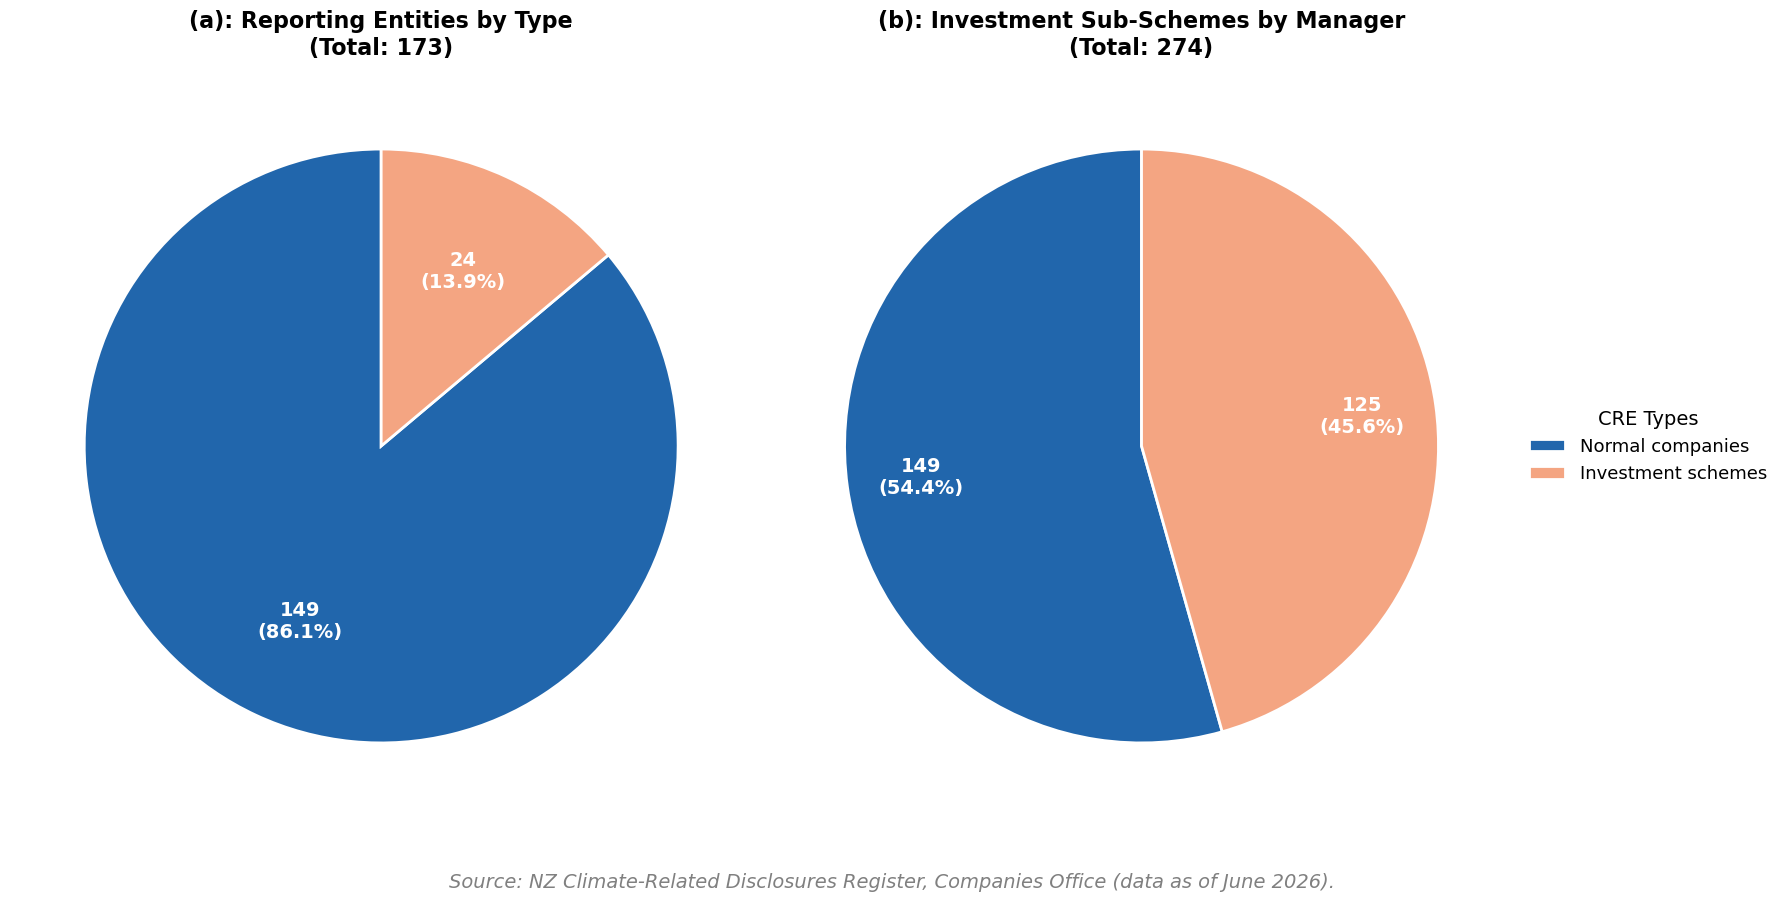

In [11]:
#Now draw two pie chart, the first pie chart is the list of unique firms in 2026 disclosure data (normal firm and schemes), 
# the second pie chart is the list of sub schemes from the scheme. 
# The two pie charts should be side by side for easy comparison.
# Clean qualitative — colorblind-safe
COLORS = [ '#2166AC', '#F4A582', '#A6DBA0']

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.patch.set_facecolor('white')
# ── Pie 1 ──────────────────────────────────────────────────────────────────────
unique_firms = disclose_2026.drop_duplicates(subset='Company Name')
type_counts  = unique_firms['Type'].value_counts()

wedges1, texts1, autotexts1 = axes[0].pie(
    type_counts,
    labels=None,
    autopct=make_autopct(type_counts),
    startangle=90,
    colors=COLORS,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    pctdistance=0.65,
    textprops=dict(fontsize=14, fontweight='bold'),
)
for at in autotexts1:
    at.set_color('white')


axes[0].set_title(f'(a): Reporting Entities by Type\n(Total: {len(unique_firms)})',
                  pad=15, fontsize=16)

# ── Pie 2 ──────────────────────────────────────────────────────────────────────
scheme_firms  =disclose_2026.drop_duplicates(subset='Company_Scheme')
scheme_counts = scheme_firms['Type'].value_counts()

threshold   = 2
other_count = scheme_counts[scheme_counts <= threshold].sum()
scheme_counts = scheme_counts[scheme_counts > threshold]
if other_count > 0:
    scheme_counts['Other'] = other_count

wedges2, texts2, autotexts2 = axes[1].pie(
    scheme_counts,
    labels=None,
    autopct=make_autopct(scheme_counts),
    startangle=90,
    colors=COLORS,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    pctdistance=0.75,
    textprops=dict(fontsize=14, fontweight='bold'),
)
for at in autotexts2:
    at.set_color('white')

axes[1].legend(
    wedges2, scheme_counts.index,
    title='CRE Types', title_fontsize=14,
    loc='center left', bbox_to_anchor=(1.0, 0.5),
    frameon=False, fontsize=13,
)
axes[1].set_title(f'(b): Investment Sub-Schemes by Manager\n(Total: {len(scheme_firms)})',
                  pad=15, fontsize=16)

# ── Caption ────────────────────────────────────────────────────────────────────
fig.text(0.5, -0.01,
         'Source: NZ Climate-Related Disclosures Register, Companies Office (data as of June 2026).',
         ha='center', fontsize=14, color='grey', style='italic')

plt.tight_layout()
plt.savefig(os.path.join(FIG_FOLDER,  'Fig01_disclosure_pie_charts.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()



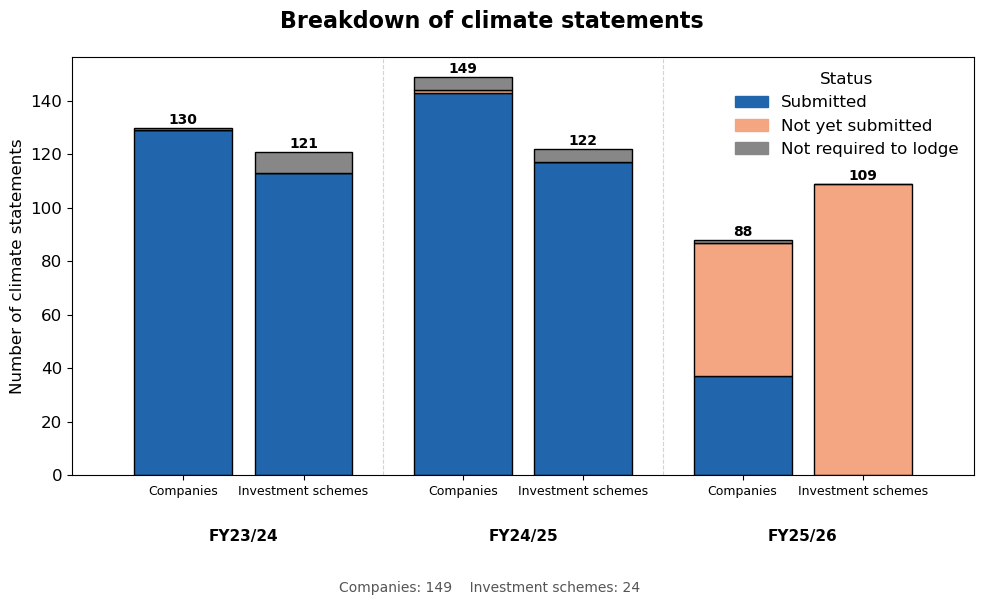

In [12]:
### Now, breakdown by the cohort and status — single plot, N vs I clustered by cohort
unique_2026 = disclose_2026.drop_duplicates(subset=['Company_Scheme', 'PeriodDate'])

STATUS_COLORS = {
    'Submitted':             '#2166AC',
    'Not yet submitted':     '#F4A582',
    'Not required to lodge': '#878787',
    'Unknown':               '#D1D1D1',
}

normal = unique_2026[unique_2026['Type'] != 'Investment schemes']
invest = unique_2026[unique_2026['Type'] == 'Investment schemes']

def make_pivot(df):
    return df.pivot_table(index='Cohort', columns='Status', values='Company_Scheme',
                          aggfunc='count', observed=True)

pt_normal = make_pivot(normal)
pt_invest = make_pivot(invest)

# Align rows and columns across both pivots
all_statuses = [s for s in STATUS_COLORS if s in pt_normal.columns or s in pt_invest.columns]
all_cohorts  = sorted(set(pt_normal.index) | set(pt_invest.index))
pt_normal = pt_normal.reindex(index=all_cohorts, columns=all_statuses)
pt_invest = pt_invest.reindex(index=all_cohorts, columns=all_statuses)

n     = len(all_cohorts)
bar_w = 0.35
pad   = 0.08

group_centers = np.arange(n, dtype=float)
x_n = group_centers - bar_w / 2 - pad / 2
x_i = group_centers + bar_w / 2 + pad / 2

fig, ax = plt.subplots(figsize=(10, 6))

bottom_n = np.zeros(n)
bottom_i = np.zeros(n)

for status in all_statuses:
    vals_n = pt_normal[status].fillna(0).values
    vals_i = pt_invest[status].fillna(0).values
    ax.bar(x_n, vals_n, bar_w, bottom=bottom_n, color=STATUS_COLORS[status], edgecolor = 'black')
    ax.bar(x_i, vals_i, bar_w, bottom=bottom_i, color=STATUS_COLORS[status], edgecolor = 'black')
    bottom_n += vals_n
    bottom_i += vals_i

# Totals on top of each stacked bar
for i in range(n):
    if bottom_n[i] > 0:
        ax.text(x_n[i], bottom_n[i] + 0.4, str(int(bottom_n[i])),
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    if bottom_i[i] > 0:
        ax.text(x_i[i], bottom_i[i] + 0.4, str(int(bottom_i[i])),
                ha='center', va='bottom', fontweight='bold', fontsize=10)

# X-axis: N / I sub-labels at each bar, cohort label at group center below
all_bar_x, all_bar_lbl = [], []
for i in range(n):
    all_bar_x.extend([x_n[i], x_i[i]])
    all_bar_lbl.extend(['Companies', 'Investment schemes'])
ax.set_xticks(all_bar_x)
ax.set_xticklabels(all_bar_lbl, fontsize=9)

trans = ax.get_xaxis_transform()
for i, cohort in enumerate(all_cohorts):
    ax.text(group_centers[i], -0.13, str(cohort), ha='center', va='top',
            fontsize=11, fontweight='bold', transform=trans)

# Dashed separator between cohort groups
for i in range(n - 1):
    ax.axvline((group_centers[i] + group_centers[i + 1]) / 2,
               color='lightgrey', linestyle='--', linewidth=0.8)

ax.set_ylabel('Number of climate statements')
ax.set_xlabel('')
ax.margins(x=0.08)
ax.set_ylim(bottom=0)

# Status legend (top-right)
status_handles = [plt.Rectangle((0, 0), 1, 1, color=STATUS_COLORS[s]) for s in all_statuses]
ax.legend(status_handles, all_statuses, title='Status', loc='upper right', frameon=False)

# Type annotation below chart
unique_firms = disclose_2026.drop_duplicates(subset='Company Name')
type_counts  = unique_firms['Type'].value_counts()
n_companies = type_counts['Normal companies']
n_schemes = type_counts['Investment schemes']

fig.text(0.5, 0.01, f'Companies: {n_companies}    Investment schemes: {n_schemes} ',
         ha='center', fontsize=10, color='#555')

fig.suptitle('Breakdown of climate statements', fontweight='bold', fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(os.path.join(FIG_FOLDER, 'Fig02_disclosure_overtime_bystatus_uniqueCREs.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### Now, explode each line into multiple pdf files and I also have a list of files that I have manually checked to ensure to include

In [ ]:
disclose_2026 = pd.read_csv(os.path.join(INTERIM_FOLDER, 'List_of_all_disclosures_as_of_2026_mapped.csv'))
included_pdf = pd.read_csv(os.path.join(INTERIM_FOLDER, 'Included_PDF_only.csv'))

#Explore 
disclose_2026['pdf_files'] = disclose_2026['pdf_files'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) else x
)

disclose_2026_exploded = (
    disclose_2026
    .explode('pdf_files')
    .dropna(subset=['pdf_files'])
    .reset_index(drop=True)
)


print(f'The number of disclosure is {disclose_2026.shape[0]}')
print(f'The number of disclosed PDF is {disclose_2026_exploded.shape[0]}')
#Then remove those without file
disclose_2026_exploded =disclose_2026_exploded[(disclose_2026_exploded['pdf_count']>0) ]
print(f'The number of disclosed PDF after remove those with 0 is {disclose_2026_exploded.shape[0]}')
# Then remove those with investment schemes 
disclose_2026_exploded = disclose_2026_exploded[disclose_2026_exploded['Type']!='Investment schemes']
print(f'The number of disclosed PDF for normal firms is {disclose_2026_exploded.shape[0]}')
# Then remove those in 2026 cohort 
disclose_2026_exploded = disclose_2026_exploded[disclose_2026_exploded['Cohort']!='Cohort 3 (Jul 2025 – Jun 2026)']
print(f'The number of disclosed PDF for normal firms in 2024-2025 is {disclose_2026_exploded.shape[0]}')
# Then I have use a manual selection of PDF to be included
disclose_2026_exploded = pd.merge(disclose_2026_exploded,
                                  included_pdf,
                                  how = 'left',
                                  left_on = ['Company_Scheme', 'Cohort','pdf_files'],
                                  right_on =['Company_Scheme', 'Cohort','pdf_files'] )
disclose_2026_exploded = disclose_2026_exploded.drop_duplicates(subset = ['pdf_files'])
disclose_2026_exploded = disclose_2026_exploded[disclose_2026_exploded['FinalInclusion'] ==1]
# Rename investment schemes into Finance other 
disclose_2026_exploded['Industry'] = np.where(
    disclose_2026_exploded['Industry'] == 'Investment Schemes',
    'Finance - Other',
    disclose_2026_exploded['Industry']
)
disclose_2026_exploded['Industry'] = np.where(
    disclose_2026_exploded['Industry'] == 'Other (Industrials, Consumer, Tech, Transport, etc.)',
    'Other industries',
    disclose_2026_exploded['Industry']
)
print(f'The number of disclosed PDF for normal firms in 2024-2025 is {disclose_2026_exploded.shape[0]}')
#Remove one file 
disclose_2026_exploded = disclose_2026_exploded[disclose_2026_exploded["pdf_files"]!="CRD 2023 CEO Declaration.pdf"]
print(f'The number of disclosed PDF for normal firms in 2024-2025 is {disclose_2026_exploded.shape[0]}')
#disclose_2026_exploded.to_csv(os.path.join(INTERIM_FOLDER, 'List_of_selected_PDF_forLLManalysis.csv'))

# ---- EXCLUDE specific company-year combinations ----
exclude_list = [
    ("ANZ GROUP HOLDINGS LIMITED", 2024),
    ("HENDERSON FAR EAST INCOME LIMITED", 2024),
    ("INSURANCE AUSTRALIA GROUP LIMITED", 2024),
    ("INSURANCE AUSTRALIA GROUP LIMITED", 2025),
    ("THE BANKERS INVESTMENT TRUST PLC", 2024),
    ("WORKS FINANCE (NZ) LIMITED", 2024),
    ("WORKS FINANCE (NZ) LIMITED", 2025),
]

exclude_set = set(exclude_list)

disclose_2026_exploded = disclose_2026_exploded[
    ~disclose_2026_exploded.apply(
        lambda r: (r['Company Name'], r['period_year']) in exclude_set,
        axis=1
    )
]
print(f'Company-year groups to process after exclusion: {len(disclose_2026_exploded)}')

The number of disclosure is 743
The number of disclosed PDF is 3206
The number of disclosed PDF after remove those with 0 is 3206
The number of disclosed PDF for normal firms is 410
The number of disclosed PDF for normal firms in 2024-2025 is 410
The number of disclosed PDF for normal firms in 2024-2025 is 235
The number of disclosed PDF for normal firms in 2024-2025 is 234
Company-year groups to process after exclusion: 227


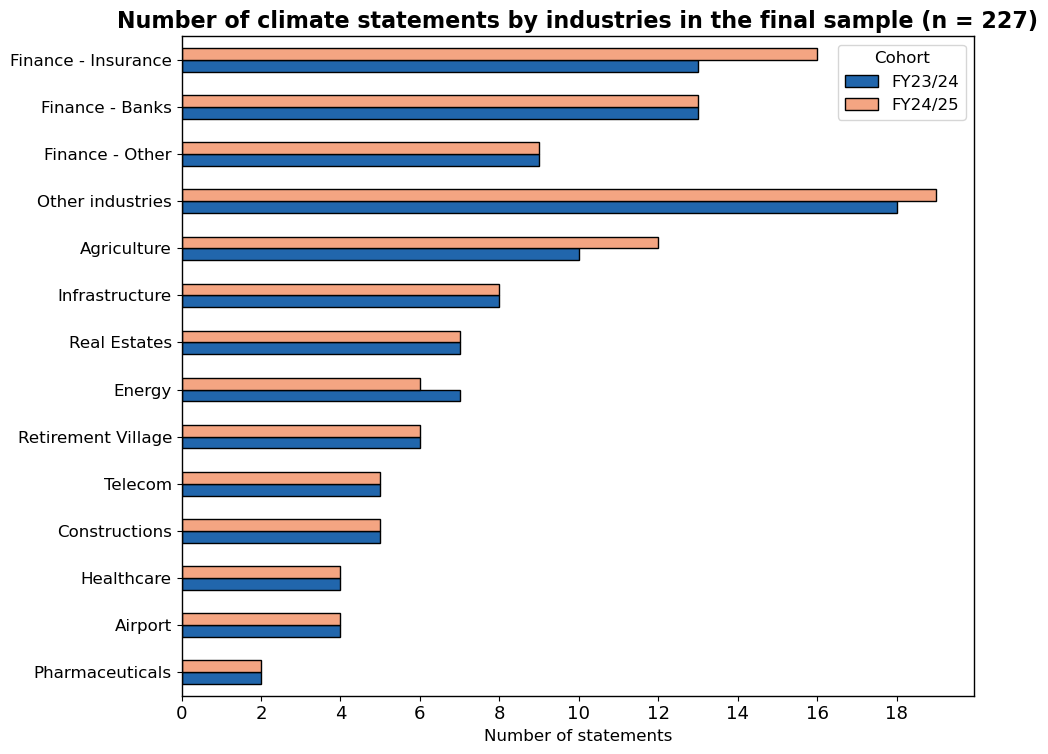

In [17]:
### Breakdown by industry — Finance vs Non-Finance grouped

finance_industries = ['Finance - Banks', 'Finance - Insurance', 'Finance - Other']

pivot_table = disclose_2026_exploded.pivot_table(
    index='Industry', columns='Cohort', values='Company_Scheme', aggfunc='count'
)

# Sort each group by total (ascending → largest at top in barh)
def sort_by_total(df, idx):
    sub = df.loc[[i for i in idx if i in df.index]]
    return sub.loc[sub.sum(axis=1).sort_values().index].index.tolist()

fin_idx      = [i for i in pivot_table.index if i in finance_industries]
other_idx    = [i for i in pivot_table.index if i not in finance_industries]
fin_sorted   = sort_by_total(pivot_table, fin_idx)
other_sorted = sort_by_total(pivot_table, other_idx)

# Non-Finance at bottom, Finance at top
pivot_table = pivot_table.loc[other_sorted + fin_sorted]

n_other   = len(other_sorted)
n_finance = len(fin_sorted)
n_total   = len(pivot_table)


COHORT_COLORS = {'FY23/24': '#2166AC', 'FY24/25': '#F4A582'}
colors = [COHORT_COLORS[c] for c in pivot_table.columns]

fig, ax = plt.subplots(figsize=(10, max(4, n_total * 0.55)))
pivot_table.plot(kind='barh', stacked=False, ax=ax, color=colors,
                 edgecolor='black')
ax.grid(visible=False)
ax.tick_params(axis='x', labelsize=13)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_title(f'Number of climate statements by industries in the final sample (n = {disclose_2026_exploded.shape[0]})', fontweight='bold', fontsize=16)
ax.set_xlabel('Number of statements')
ax.set_ylabel('')
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

plt.tight_layout()
plt.savefig(os.path.join(FIG_FOLDER, 'Fig03_disclosure_overtime_by_industry.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
